## ***NHẬT KÝ THỰC HÀNH***

+ 15/10: Đọc yêu cầu thực hành, đọc tài liệu tham khảo, tạo môi trường thực hành.
+ 16/10: 
    + Tạo templates.
    + Hoàn thành tiền xử lí dữ liệu, trực quan dữ liệu, chuẩn hóa dữ liệu và chia tập dữ liệu.
    + Đã hoàn thành phần đầu chuẩn bị cho quá trình thử nghiệm mô hình tiếp theo.

## **Định nghĩa vấn đề**

In [154]:
from PIL import Image
import matplotlib.pyplot as plt
image1 = Image.open("Iris_setosa.jpg"); image2 = Image.open("Iris_versicolor.jpg"); image3 = Image.open("Iris_virginica.jpg")

+ **Mô tả**:
    + Bộ dữ liệu bao gồm 50 mẫu từ mỗi loài trong số ba loài Iris (Iris setosa, Iris virginica và Iris versicolor). 
    + Bốn đặc điểm được đo từ mỗi mẫu: chiều dài và chiều rộng của các lá đài(sepal) và cánh hoa (petal), tính bằng cm.
+ **Dữ liệu vào**:
    + sepal length (cm)
    + sepal width (cm)
    + petal length (cm)
    + petal width (cm)
+ **Kết quả**: class (Iris Setosa, Iris Versicolour, Iris Virginica)

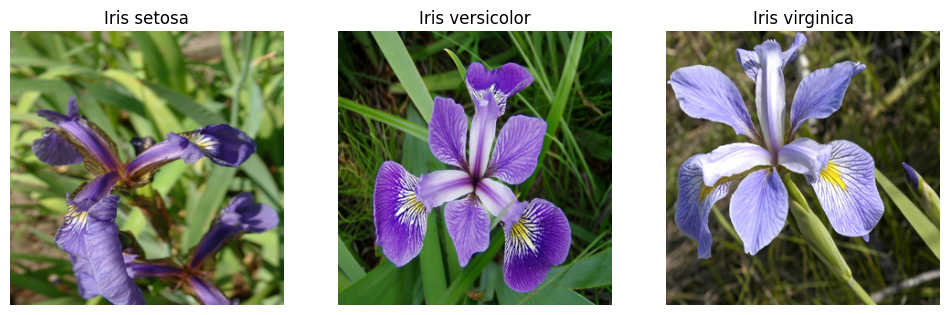

In [155]:
plt.figure(figsize=(12,12))
plt.subplot(1,3,1), plt.imshow(image1.resize((300,300))), plt.axis("off"), plt.title("Iris setosa")
plt.subplot(1,3,2), plt.imshow(image2.resize((300,300))), plt.axis("off"), plt.title("Iris versicolor")
plt.subplot(1,3,3), plt.imshow(image3.resize((300,300))), plt.axis("off"), plt.title("Iris virginica")
plt.show()

## **Chuẩn bị vấn đề**

### **Khai báo thư viện**

In [156]:
# Load libraries
import os, sys
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

import warnings

%matplotlib inline
# plt.rcParams["figure.figsize"] = (12, 6)
# plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings("ignore")

### **Tải tập dữ liệu**

In [157]:
# Load dataset
data_path  = "iris.csv"
data_names = ["sepal-length", "sepal-width", "petal-length", "petal-width", "class"]
df_dataset = pd.read_csv(data_path, names = data_names)

## **Phân tích khám phá dữ liệu**

### **Thống kê mô tả**

#### **Hiển thị một số thông tin về dữ liệu**

In [158]:
# shape
print(f'+ Shape: {df_dataset.shape}')
# types
print(f'+ Data Types: \n{df_dataset.dtypes}')
# head, tail
print(f'+ Contents: ')
display.display(df_dataset.head(5))
display.display(df_dataset.tail(5))
# info
df_dataset.info()

+ Shape: (150, 5)
+ Data Types: 
sepal-length    float64
sepal-width     float64
petal-length    float64
petal-width     float64
class            object
dtype: object
+ Contents: 


,sepal-length,sepal-width,petal-length,petal-width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


,sepal-length,sepal-width,petal-length,petal-width,class
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal-length  150 non-null    float64
 1   sepal-width   150 non-null    float64
 2   petal-length  150 non-null    float64
 3   petal-width   150 non-null    float64
 4   class         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


> **Nhận xét:** 
+ Dữ liệu có 4 tính chất để phân lớp: sepal-length, sepal-width, petal-length, petal-width
+ Giá trị 4 tính chất được tính cùng đơn vị đo (cm)
+ Tổng số dòng dữ liệu là 150 dòng
+ Dữ liệu để phân lớp ở cột class
+ Các dữ liệu có tính chất để phân lớp là kiểu dữ liệu float, và biến mục tiêu thuộc kiểu object.
+ 5 dòng đầu tiên thể hiện các giá trị của loài Iris-setosa, 5 dòng cuối thể hiện các giá trị của loài Iris-virginica, có thể thấy về giá trị sepal-length giữa 2 loài có sự khác biệt tương đối nhỏ, còn giá trị của petal-length và petal-width thì có sự khác biệt tương đối là lớn, điều này cho thấy khả năng có thể phân biệt được 2 loài là rất cao.
+ Trong tập có 150 quan sát và không có đặc trưng nào bị thiếu giá trị.

#### **Kiểm tra tính toàn vẹn của dữ liệu**

In [159]:
# Kiểm tra giá trị null
data_null = df_dataset[df_dataset.isnull().any(axis=1)]
if not data_null.empty:
    print('Số lượng dòng chứa giá trị null: ', data_null.shape[0])
    display.display(data_null)
    print("Số lượng giá trị null theo từng cột:")
    print(df_dataset.isnull().sum())
else:
    print('Không có giá trị null nào.')

Không có giá trị null nào.


In [160]:
# Kiểm tra giá trị NaN
data_nan = df_dataset[df_dataset.isna().any(axis=1)]
if not data_nan.empty:
    print('Số lượng dòng chứa giá trị null: ', data_nan.shape[0])
    display.display(data_nan)
    print("Số lượng giá trị null theo từng cột:")
    print(df_dataset.isna().sum())
else:
    print('Không có giá trị nan nào.')

Không có giá trị nan nào.


In [161]:
data_dup = df_dataset[df_dataset.duplicated(keep=False)]
if not data_dup.empty:
    print('Số hàng trùng nhau: ', df_dataset.duplicated(keep="first").sum())

    # Nhóm theo toàn bộ các cột
    grouped = data_dup.groupby(list(df_dataset.columns))

    # Duyệt và hiển thị từng nhóm
    for i, (key, group) in enumerate(grouped, start=1):
        print(f'\n nhóm trùng lặp: {i} (số dòng: {len(group)})')
        display.display(group)

    print('Tổng hợp các dòng trùng lặp')
    display.display(data_dup)
else:
    print('Không có hàng nào trùng nhau.')

Số hàng trùng nhau:  3

 nhóm trùng lặp: 1 (số dòng: 3)


,sepal-length,sepal-width,petal-length,petal-width,class
9,4.9,3.1,1.5,0.1,Iris-setosa
34,4.9,3.1,1.5,0.1,Iris-setosa
37,4.9,3.1,1.5,0.1,Iris-setosa



 nhóm trùng lặp: 2 (số dòng: 2)


,sepal-length,sepal-width,petal-length,petal-width,class
101,5.8,2.7,5.1,1.9,Iris-virginica
142,5.8,2.7,5.1,1.9,Iris-virginica


Tổng hợp các dòng trùng lặp


,sepal-length,sepal-width,petal-length,petal-width,class
9,4.9,3.1,1.5,0.1,Iris-setosa
34,4.9,3.1,1.5,0.1,Iris-setosa
37,4.9,3.1,1.5,0.1,Iris-setosa
101,5.8,2.7,5.1,1.9,Iris-virginica
142,5.8,2.7,5.1,1.9,Iris-virginica


> **Nhận xét:**
+ Dữ liệu có 3 dòng bị trùng là dòng ở vị trí 34, 37, 142
+ Dữ liệu không có giá trị rỗng (NaN, Null)

#### **Các tính chất thống kê trên dữ liệu số**

In [162]:
description = df_dataset.describe().T
display.display(description)

,count,mean,std,min,25%,50%,75%,max
sepal-length,150.0,5.843333,0.828066,4.3,5.1,5.80,6.4,7.9
sepal-width,150.0,3.054000,0.433594,2.0,2.8,3.00,3.3,4.4
petal-length,150.0,3.758667,1.764420,1.0,1.6,4.35,5.1,6.9
petal-width,150.0,1.198667,0.763161,0.1,0.3,1.30,1.8,2.5


> **Nhận xét:**
+ Có thể thấy là kích thước trung bình của sepal-length là lớn nhất lớn hơn rất nhiều so với giá trị trung bình của petal-width, điều này cho thấy sự khác biệt về kích thước của thành phần thì khác nhau
+ Độ lệch chuẩn của petal-length rất lớn khoảng 1.764, so với các đặc trưng còn lại thì chỉ được khoảng từ 0.43 đến 0.828, cho thấy sự khác biệt về các giá trị của từng biến thì khác nhau. có biến thì có độ lệch chuẩn lớn cho thấy số lượng kích thước khác nhau, điều này gây khó khăn trong việc nhận dạng đặc trưng.

#### **Tần số xuất hiện (Distribution) trên dữ liệu phân lớp (Class) và dữ liệu danh mục (Category)**

In [163]:
df_dataset["class"].value_counts()

class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

> **Nhận xét:**
+ Dữ liệu cần phân loại 3 loài hoa Iris là Iris-virginica, Iris-setosa, và Iris-versicolor
+ Các lớp là cân bằng nhau và có số lượng 50
+ Tần số xuất hiện cho thấy các lớp có số lượng quan sát cân bằng với nhau, rất có ích cho việc huấn luyện mô hình vì có thể tránh được trường hợp bị thiên vị.

#### **Mối tương quan giữa các tính chất (Correlations)**

In [164]:
correlations = df_dataset.select_dtypes(include=['number']).corr(method='pearson')
display.display(correlations)

,sepal-length,sepal-width,petal-length,petal-width
sepal-length,1.000000,-0.109369,0.871754,0.817954
sepal-width,-0.109369,1.000000,-0.420516,-0.356544
petal-length,0.871754,-0.420516,1.000000,0.962757
petal-width,0.817954,-0.356544,0.962757,1.000000


> **Nhận xét:**
+ Các cặp tính chất có độ tương đồng cao:
    + (sepal-length, petal-length) = 0.872, cho thấy khi chiều dài đài hoa tăng thì chiều dài cánh hoa cũng tăng theo.
    + (sepal-length, petal-width) = 0.818, cho thấy khi hoa có đài dài thường cũng có cánh rộng hơn.
    + (petal-length, petal-width) = 0.963, cho thấy khi cánh hoa dài hơn thì rộng hơn gần như chắc chắn.
    + Khi các cặp có tương quan quá cao thì chỉ nên giữ lại một biến để tránh đa cộng tuyến, ví dụ như cặp petal-length và petal-width.

### **Trực quan dữ liệu**

#### **Hiển thị trên từng tính chất đơn (Univariate Plots)**

**Box and whisker plots**

<Axes: >

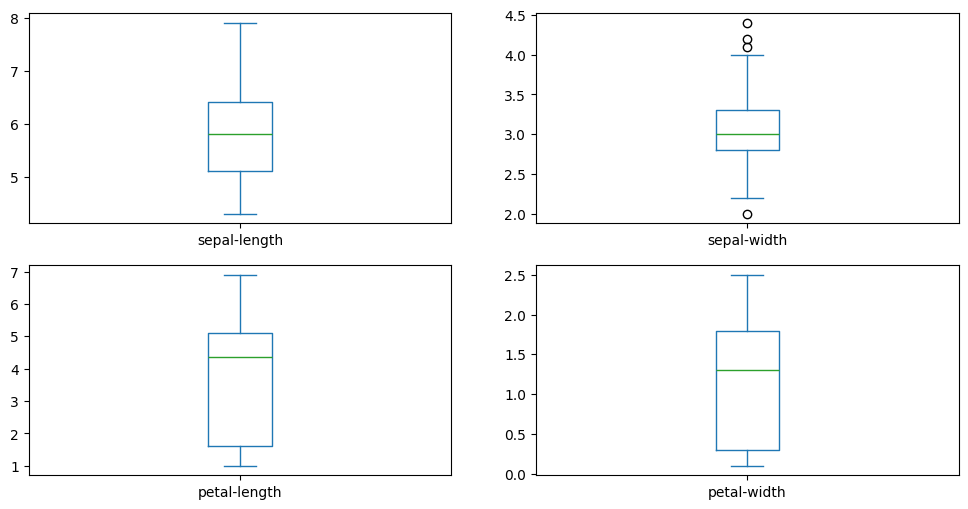

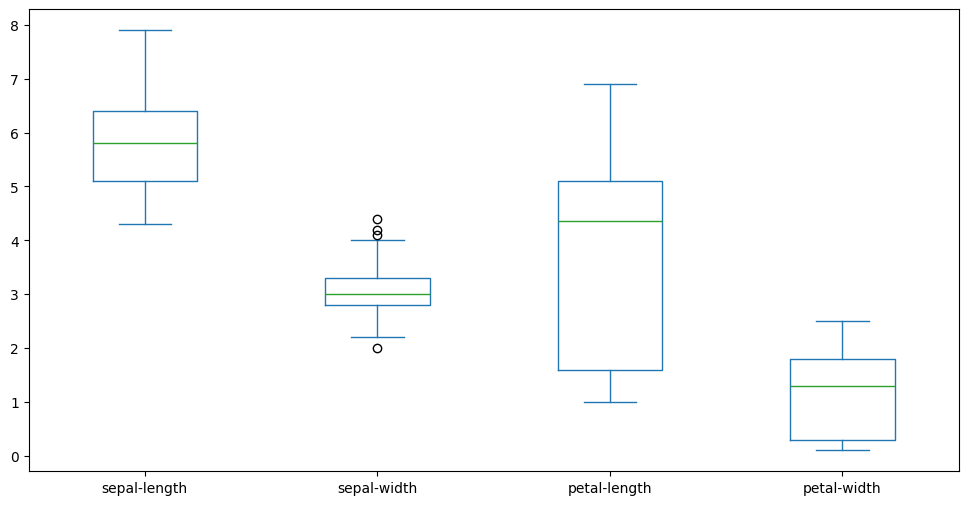

In [165]:
df_dataset.plot(kind="box", subplots=True, layout=(2, 2), sharex=False, sharey=False, figsize=(12,6))
df_dataset.plot(kind="box", figsize=(12,6))

> **Nhận xét:**
+ Độ trải rộng giữa các tính chất khá khác nhau (sepal-width, sepal-length, petal-width, petal-length)
+ Độ lệch của sepal-length, petal-length, petal-width theo hướng giá trị nhỏ.
+ Phân bố giá trị của sepal-width khá cân bằng

**Biểu đồ Histogram**

array([[<Axes: title={'center': 'sepal-length'}>,
        <Axes: title={'center': 'sepal-width'}>],
       [<Axes: title={'center': 'petal-length'}>,
        <Axes: title={'center': 'petal-width'}>]], dtype=object)

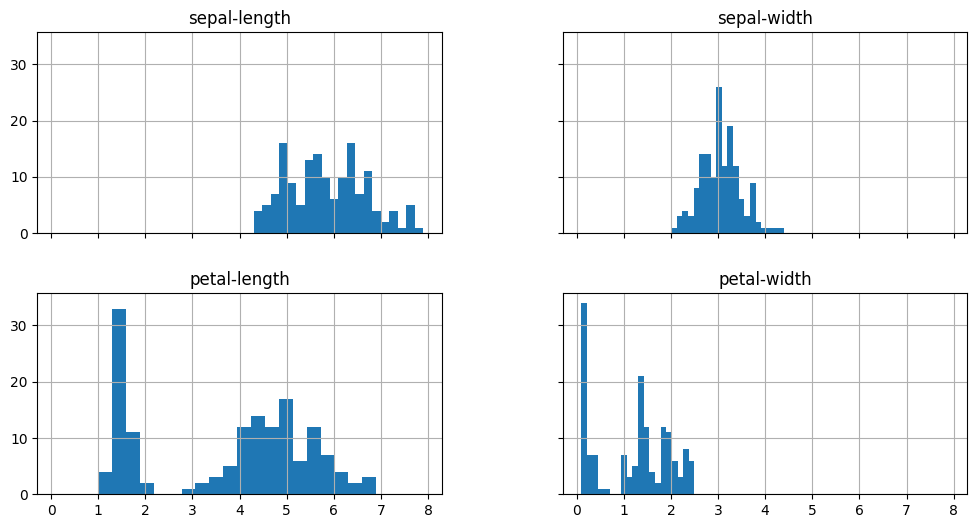

In [166]:
df_dataset.hist(figsize=(12, 6), bins = 20, sharex = True, sharey = True)

> **Nhận xét:**
+ Các kích thước của đài hoa có xu hương phân phối gần chuẩn hoặc không phân cụm rõ rệt
+ Còn các kích thước của cánh hóa có xu hướng phân thành hai cạm rõ rệt.

#### **Hiển thị nhiều tính chất (Multivariate Plots)**

array([[<Axes: xlabel='sepal-length', ylabel='sepal-length'>,
        <Axes: xlabel='sepal-width', ylabel='sepal-length'>,
        <Axes: xlabel='petal-length', ylabel='sepal-length'>,
        <Axes: xlabel='petal-width', ylabel='sepal-length'>],
       [<Axes: xlabel='sepal-length', ylabel='sepal-width'>,
        <Axes: xlabel='sepal-width', ylabel='sepal-width'>,
        <Axes: xlabel='petal-length', ylabel='sepal-width'>,
        <Axes: xlabel='petal-width', ylabel='sepal-width'>],
       [<Axes: xlabel='sepal-length', ylabel='petal-length'>,
        <Axes: xlabel='sepal-width', ylabel='petal-length'>,
        <Axes: xlabel='petal-length', ylabel='petal-length'>,
        <Axes: xlabel='petal-width', ylabel='petal-length'>],
       [<Axes: xlabel='sepal-length', ylabel='petal-width'>,
        <Axes: xlabel='sepal-width', ylabel='petal-width'>,
        <Axes: xlabel='petal-length', ylabel='petal-width'>,
        <Axes: xlabel='petal-width', ylabel='petal-width'>]], dtype=object)

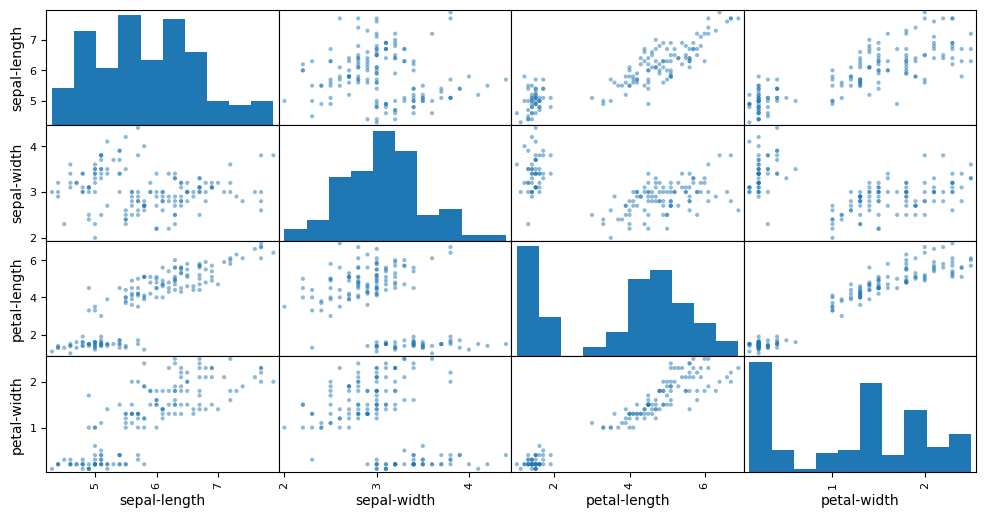

In [167]:
pd.plotting.scatter_matrix(df_dataset, figsize=(12,6))

> **Nhận xét:**
+ Cặp (sepal-length, petal-length) có sự tương quan cao do petal-length tạo thành một đường chéo tăng lên rõ rệt, khi sepal-length tăng thì xu hướng petal-length cũng tăng.
+ Cặp (sepal-length, petal-width) cũng có sự tương quan nhưng yếu hơn.
+ Cặp (petal-length, petal-width) cho thấy sự tương quan rất cao khi các điểm tập trung thành một đường chéo.

#### **Hiển thị mối tương quan giữa các biến với nhau bằng biểu đồ heatmap**

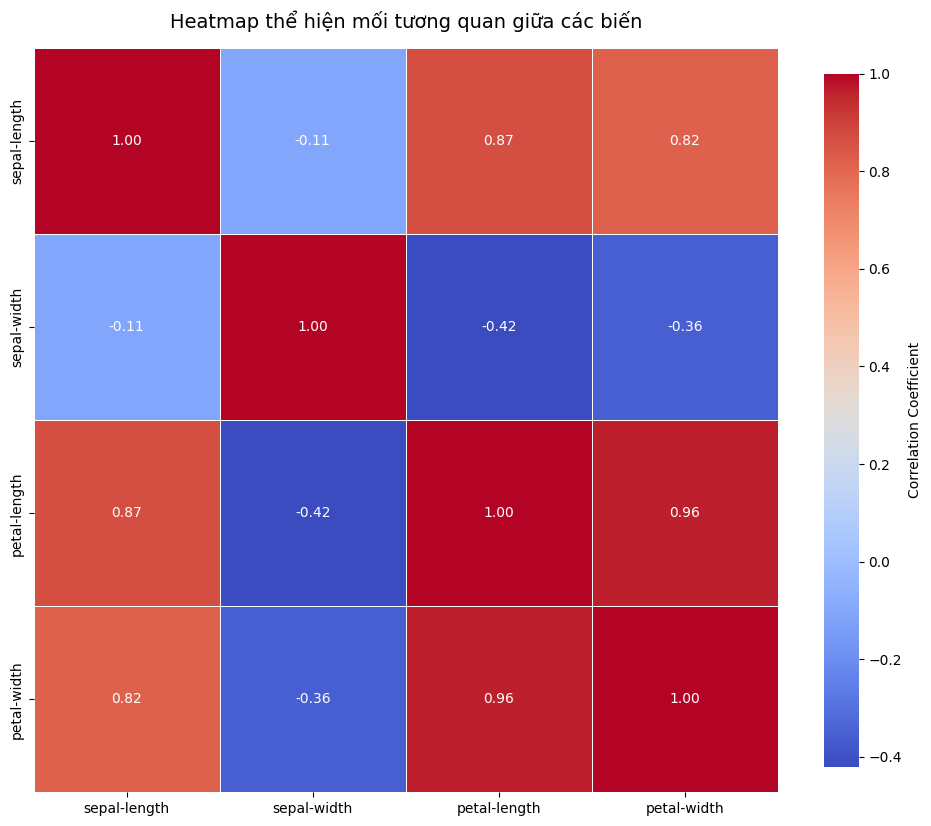

In [168]:

plt.figure(figsize=(12,12))
sns.heatmap(
    correlations,
    annot=True, #hien thi gtri tren cac o
    fmt = ".2f", #lam tron 2 chu so thap phan
    cmap = "coolwarm", #bang mau 
    linewidths=0.5, #khoang cach giua cac o
    square=True, # hien thi o vuong cho dep
    cbar_kws={"shrink": 0.75, "label": "Correlation Coefficient"} #thanh mau ben phai
)
plt.title("Heatmap thể hiện mối tương quan giữa các biến", fontsize = 14, pad=15)
plt.show()

> **Nhận xét:**
+ Hiển thị biểu đồ heatmap có thể trực quan rõ ràng sự tương quan giữa các đặc trưng với nhau qua màu sắc và số liệu được hiển thị trên biểu đồ.

## **Chuẩn bị dữ liệu + xử lý đặc trưng**

### **Làm sạch dữ liệu (Data Cleaning)**

#### **Tạo bảng dữ liệu làm sạch**
+ Chỉ giữ lại các cột Input, Output

In [169]:
df_clean = df_dataset.copy()

#### **Xử lý dữ liệu trùng nhau**

In [170]:
display.display(df_dataset[df_dataset.duplicated()])

,sepal-length,sepal-width,petal-length,petal-width,class
34,4.9,3.1,1.5,0.1,Iris-setosa
37,4.9,3.1,1.5,0.1,Iris-setosa
142,5.8,2.7,5.1,1.9,Iris-virginica


In [171]:
# Duyệt và hiển thị từng nhóm
for i, (key, group) in enumerate(grouped, start=1):
    print(f'\n nhóm trùng lặp: {i} (số dòng: {len(group)})')
    display.display(group)


 nhóm trùng lặp: 1 (số dòng: 3)


,sepal-length,sepal-width,petal-length,petal-width,class
9,4.9,3.1,1.5,0.1,Iris-setosa
34,4.9,3.1,1.5,0.1,Iris-setosa
37,4.9,3.1,1.5,0.1,Iris-setosa



 nhóm trùng lặp: 2 (số dòng: 2)


,sepal-length,sepal-width,petal-length,petal-width,class
101,5.8,2.7,5.1,1.9,Iris-virginica
142,5.8,2.7,5.1,1.9,Iris-virginica


In [172]:
df_clean.drop_duplicates(ignore_index=True, inplace=True)
df_clean

,sepal-length,sepal-width,petal-length,petal-width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
142,6.7,3.0,5.2,2.3,Iris-virginica
143,6.3,2.5,5.0,1.9,Iris-virginica
144,6.5,3.0,5.2,2.0,Iris-virginica
145,6.2,3.4,5.4,2.3,Iris-virginica


> **Nhận xét:**
+ Loại bỏ các giả trị trùng lập giúp cho mô hình sẽ đạt được hiệu suất tốt hơn.

#### **Xử lý giá trị rỗng, không hợp lệ**

In [173]:
has_null = df_dataset.isnull().sum().any()
has_nan  = df_dataset.isna().sum().any()
print(f'+ Có giá trị Null: {has_null}')
if has_null:
    display.display(df_dataset[df_dataset.isnull().any(axis=1)])
print(f'+ Có giá trị Nan: {has_nan}')
if has_nan:
    display.display(df_dataset[df_dataset.isna().any(axis=1)])

+ Có giá trị Null: False
+ Có giá trị Nan: False


> **Nhận xét:**
+ Rất tốt khi không có dữ liệu nào bị thiếu trong tập dữ liệu, vì thế ta không cần phải thực hiện thao tác xử lý dữ liệu null/nan.

### **Lựa chọn đặc trưng (Feature Selection)**

none

### **Biến đổi dữ liệu (Data Transforms)**

#### **Chuyển đổi dữ liệu danh mục (Category) thành dữ liệu số**

In [174]:
class_encoder = LabelEncoder()
class_encoder.fit(df_clean["class"])
class_names = class_encoder.classes_
print(class_names)

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [175]:
class_encoder.transform(df_clean["class"])

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [176]:
df_clean["class"] = class_encoder.transform(df_clean["class"])
df_clean

,sepal-length,sepal-width,petal-length,petal-width,class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
142,6.7,3.0,5.2,2.3,2
143,6.3,2.5,5.0,1.9,2
144,6.5,3.0,5.2,2.0,2
145,6.2,3.4,5.4,2.3,2


> **Nhận xét:**
+ Biến đổi các đặc trưng là biến định tính thành biến định lượng, điều này phù hợp khi ta cần chuẩn hóa hóa dữ liệu cho việc huấn luyện mô hình, khi nào mô hình không thể đọc được giá trị là kiểu ký tự.
+ Ngoài ra, còn góp phần làm ổn định mô hình và tăng tính chính xác khi huấn luyện mô hình.

#### **Chuyển đổi dữ liệu danh mục (Category) thành dạng OneHot**

#### **Chuẩn hóa dữ liệu (Data Normalize)**

In [177]:
# Min-Max Normalization
scale_columns = ["sepal-length", "sepal-width", "petal-length", "petal-width"]
minmax_scaler = MinMaxScaler()
minmax_scaler.fit(df_clean[scale_columns])
df_clean_minmax = df_clean.copy()
df_clean_minmax[scale_columns] = minmax_scaler.transform(df_clean[scale_columns])
df_clean_minmax

,sepal-length,sepal-width,petal-length,petal-width,class
0,0.222222,0.625000,0.067797,0.041667,0
1,0.166667,0.416667,0.067797,0.041667,0
2,0.111111,0.500000,0.050847,0.041667,0
3,0.083333,0.458333,0.084746,0.041667,0
4,0.194444,0.666667,0.067797,0.041667,0
...,...,...,...,...,...
142,0.666667,0.416667,0.711864,0.916667,2
143,0.555556,0.208333,0.677966,0.750000,2
144,0.611111,0.416667,0.711864,0.791667,2
145,0.527778,0.583333,0.745763,0.916667,2


<Axes: >

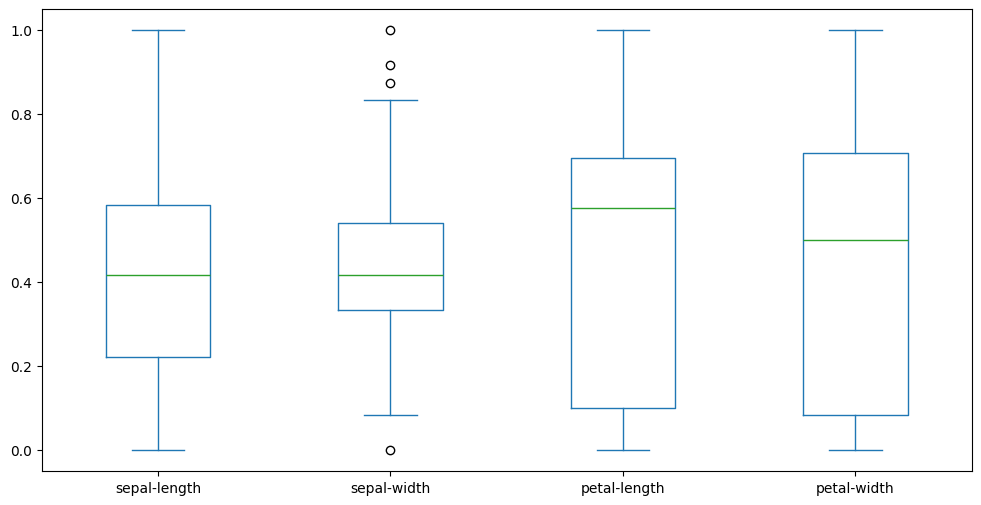

In [178]:
df_clean_minmax[scale_columns].plot(kind="box", figsize=(12,6))

> **Nhận xét:** 
+ Việc chuẩn hóa theo Min-Max Normalization đưa các giá trị về khoảng [0,1] từ đó các đặc trưng được đo ở một thước đo giống nhau, tránh việc đặc trưng có giá trị lớn lấn át các đặc trưng nhỏ hơn, đặc biệt hữu ích khi khoảng giá trị có giới hạn rõ ràng.

In [179]:
# Standard Normalization
standard_scaler = StandardScaler()
standard_scaler.fit(df_clean[scale_columns])
df_clean_standard = df_clean.copy()
df_clean_standard[scale_columns] = standard_scaler.transform(df_clean[scale_columns])
df_clean_standard

,sepal-length,sepal-width,petal-length,petal-width,class
0,-0.915509,1.019971,-1.357737,-1.335700,0
1,-1.157560,-0.128082,-1.357737,-1.335700,0
2,-1.399610,0.331139,-1.414778,-1.335700,0
3,-1.520635,0.101529,-1.300696,-1.335700,0
4,-1.036535,1.249582,-1.357737,-1.335700,0
...,...,...,...,...,...
142,1.020892,-0.128082,0.809831,1.444682,2
143,0.536792,-1.276136,0.695748,0.915085,2
144,0.778842,-0.128082,0.809831,1.047484,2
145,0.415766,0.790361,0.923913,1.444682,2


<Axes: >

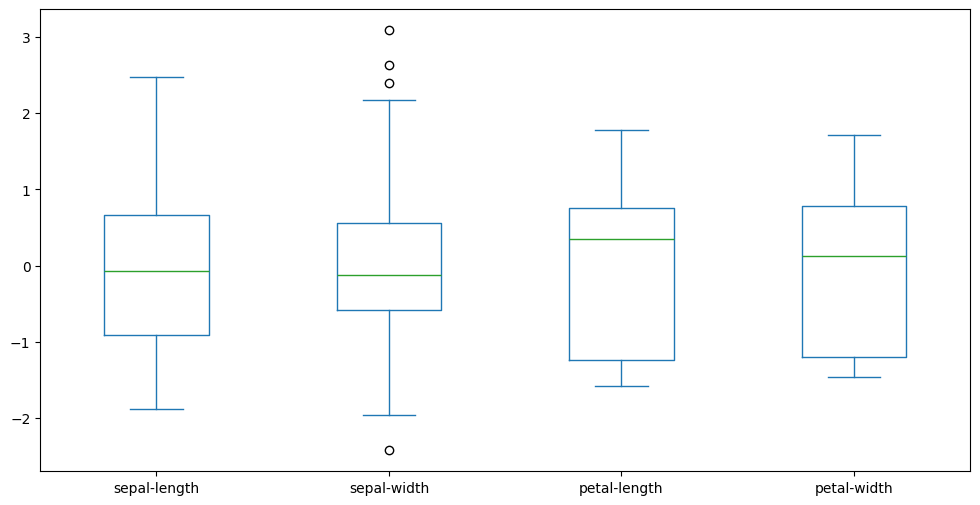

In [180]:
df_clean_standard[scale_columns].plot(kind="box", figsize=(12,6))

> **Kết luận:**
+ Dữ liệu được chuyển về phân phối có dạng chuẩn, giúp các thuật toán hội tụ nhanh hơn.
+ Loại bỏ sự lệch thang đo giữa các đặc trưng.

In [181]:
correlations = df_clean_standard.corr(method='pearson')
display.display(correlations)

,sepal-length,sepal-width,petal-length,petal-width,class
sepal-length,1.000000,-0.109321,0.871305,0.817058,0.782904
sepal-width,-0.109321,1.000000,-0.421057,-0.356376,-0.418348
petal-length,0.871305,-0.421057,1.000000,0.961883,0.948339
petal-width,0.817058,-0.356376,0.961883,1.000000,0.955693
class,0.782904,-0.418348,0.948339,0.955693,1.000000


#### **Chia dữ liệu thực nghiệm**

In [182]:
X_data, y_data = df_clean.values[:, :-1], df_clean.values[:, -1]
X_data.shape, y_data.shape
print(X_data[:20, :])
print(y_data[:20])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [183]:
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, train_size=0.7)
print(f'+ Train/Test: Train Ratio = {len(X_train)/len(X_data)}')
print(f'+ Train: shape={X_train.shape}\nInput = \n{X_train[:5]}\nOutput = {y_train[:5]}')
print(f'+ Test: shape={X_test.shape}\nInput = \n{X_test[:5]}\nOutput = {y_test[:5]}')

+ Train/Test: Train Ratio = 0.6938775510204082
+ Train: shape=(102, 4)
Input = 
[[7.4 2.8 6.1 1.9]
 [5.2 3.5 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [5.5 4.2 1.4 0.2]]
Output = [2. 0. 0. 0. 0.]
+ Test: shape=(45, 4)
Input = 
[[6.3 2.3 4.4 1.3]
 [6.1 2.6 5.6 1.4]
 [6.2 2.2 4.5 1.5]
 [5.7 2.9 4.2 1.3]
 [6.1 2.9 4.7 1.4]]
Output = [1. 2. 1. 1. 1.]


## **Huấn luyện cơ sở + Đánh giá thuật toán**

### **Tập dữ liệu kiểm tra tách riêng**

### **Tùy chọn kiểm tra và chỉ số đánh giá - Xác định các tùy chọn kiểm tra sử dụng scikit-learn như kiểm tra chéo và các thước đo đánh giá cần sử dụng.**

### **Kiểm tra ngẫu nhiên một bộ các thuật toán học máy tuyến tính và phi tuyến.**

### **So sánh các thuật toán**

## **Huấn luyện cải thiện tham số**

### **Tìm kiếm một kết hợp các tham số cho từng thuật toán sử dụng scikit-learn để đưa ra kết quả tốt nhất(Algorithm Tuning)**

### **Kết hợp dự đoán của nhiều mô hình thành một dự đoán tập hợp sử dụng các kỹ thuật tập hợp(Ensembles).**

## **Kết hợp mô hình**

### **Sử dụng một mô hình tối ưu được điều chỉnh bởi scikit-learn để đưa ra dự đoán trên dữ liệu chưa từng thấy**

### **Tạo một mô hình độc lập sử dụng các tham số đã được điều chỉnh bởi scikit-learn.**

## **Đánh giá và lưu**

In [184]:
# Lưu thông tin
save_dir = "exp"
if os.path.exists(save_dir) == False: os.makedirs(save_dir)

# Save training data
np.savez(f'{save_dir}/data.npz', X_train=X_train, X_test=X_test, y_train=y_train, y_test=y_test)
# Save cleaning data
df_clean.to_csv(f'{save_dir}/df_clean.csv', index=False)
# Save encoders
joblib.dump(class_encoder, f'{save_dir}/class_encoder.joblib')

os.listdir(save_dir)

['class_encoder.joblib', 'data.npz', 'df_clean.csv']

In [185]:
# Kiểm tra phục hồi dữ liệu
dict(np.load(f'{save_dir}/data.npz')).keys()

dict_keys(['X_train', 'X_test', 'y_train', 'y_test'])

In [186]:
pd.read_csv(f'{save_dir}/df_clean.csv')

,sepal-length,sepal-width,petal-length,petal-width,class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
142,6.7,3.0,5.2,2.3,2
143,6.3,2.5,5.0,1.9,2
144,6.5,3.0,5.2,2.0,2
145,6.2,3.4,5.4,2.3,2


In [187]:
joblib.load(f'{save_dir}/class_encoder.joblib').classes_

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)